# High-Value Customer Behavior Simulation for a FinTech Subscription Service

## Section S01 — Data Generation

This notebook uses the reusable generators in `src/generators.py` and the workflow helpers in `src/workflows.py`.
All generated datasets now use business-facing columns:

- `avg_transaction`
- `frequency`
- `credit_score`
- `vip_status`


In [1]:
from src.notebook_utils import ensure_project_root_on_path, RAW_DATA, CHECKPOINT_DATA, SYNTHETIC_DIR
ensure_project_root_on_path()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')

from src.generators import get_generator
from src.workflows import create_vip_seed_data, save_dataset


In [2]:
seed_df = create_vip_seed_data(samples=1000, random_state=42)
seed_df.head()


,avg_transaction,frequency,credit_score,vip_status
0,55.66,14,737.0,0
1,41.71,11,663.0,0
2,63.73,7,761.0,0
3,38.31,14,772.0,0
4,43.33,14,613.0,0


In [3]:
seed_df.describe().T


,count,mean,std,min,25%,50%,75%,max
avg_transaction,1000.0,50.66778,21.106595,5.0,36.5425,47.08,60.8675,189.78
frequency,1000.0,11.80200,3.509860,3.0,9.0000,12.00,14.0000,22.00
credit_score,1000.0,718.28000,54.019346,519.0,682.0000,720.00,752.0000,850.00
vip_status,1000.0,0.02700,0.162164,0.0,0.0000,0.00,0.0000,1.00


In [4]:
generated = {}
for method in ['random', 'specialized', 'gan']:
    df = get_generator(method).generate(1000, random_state=42)
    generated[method] = df
    save_dataset(df, SYNTHETIC_DIR / f'vip_{method}.csv')

generated['random'].head()


,avg_transaction,frequency,credit_score,vip_status
0,39.67,11,720.0,0
1,23.45,9,632.0,0
2,20.37,6,749.0,0
3,59.07,12,761.0,0
4,31.97,12,573.0,0


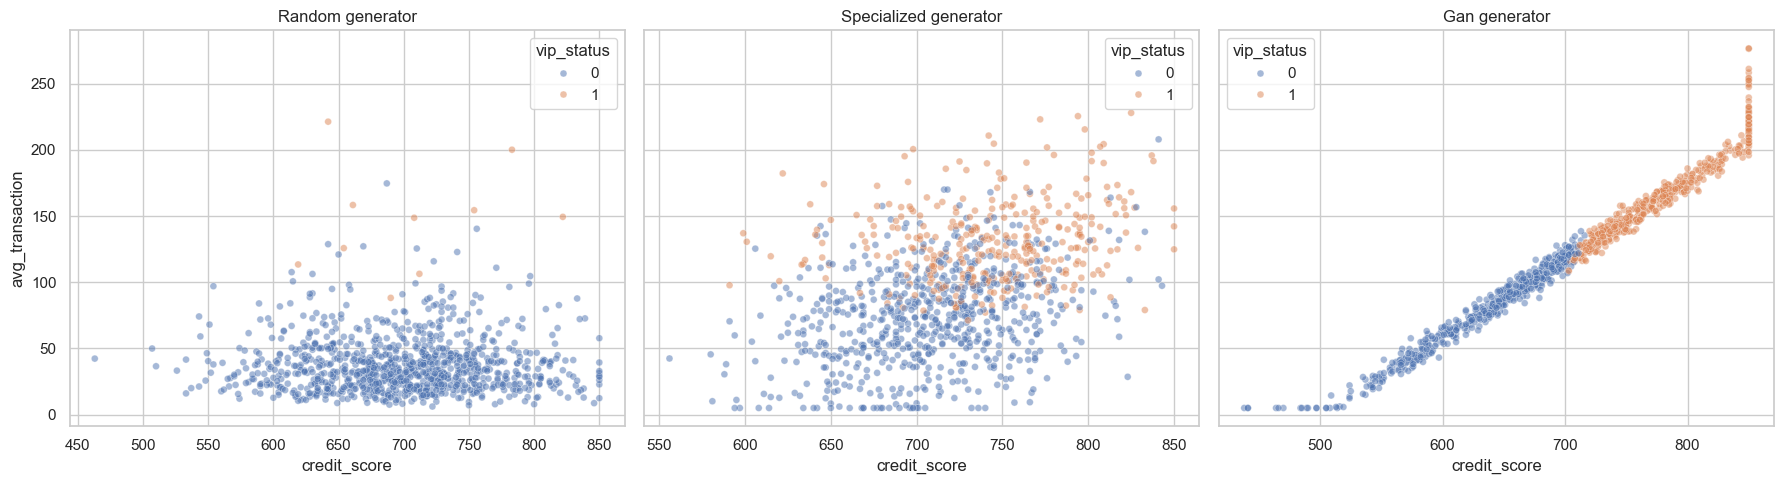

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (method, df) in zip(axes, generated.items()):
    sns.scatterplot(data=df, x='credit_score', y='avg_transaction', hue='vip_status', alpha=0.5, s=25, ax=ax)
    ax.set_title(f'{method.title()} generator')
plt.tight_layout()
